In [2]:
#Imports and data loading
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze("columns")
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze("columns")

print("X_train shape:", X_train.shape)
print("y_train distribution:\n", y_train.value_counts(normalize=True))

X_train shape: (188296, 1)
y_train distribution:
 label
1    0.572928
0    0.427072
Name: proportion, dtype: float64


In [3]:
#Basic URL statistics
# Add a column for URL length
X_train['url_length'] = X_train['URL'].str.len()
X_test['url_length'] = X_test['URL'].str.len()

# Combine with labels for analysis
train_df = X_train.copy()
train_df['label'] = y_train.values

print(train_df.head())

                                                 URL  url_length  label
0  https://xxx.7a7.myftpupload.com/.pki/nssdb/frt...          92      0
1                     https://www.jesuisanimateur.fr          30      1
2                                http://www.e100.net          19      0
3                https://www.apocalypselaterfilm.com          35      1
4  https://b4e921f0.sso-mailsrvr-4344e5teed.pages...        5795      0


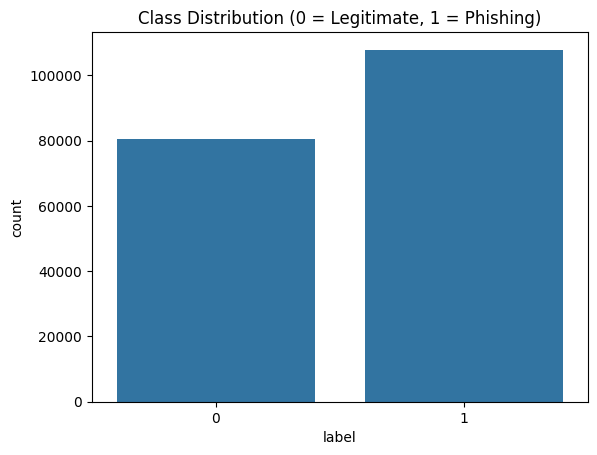

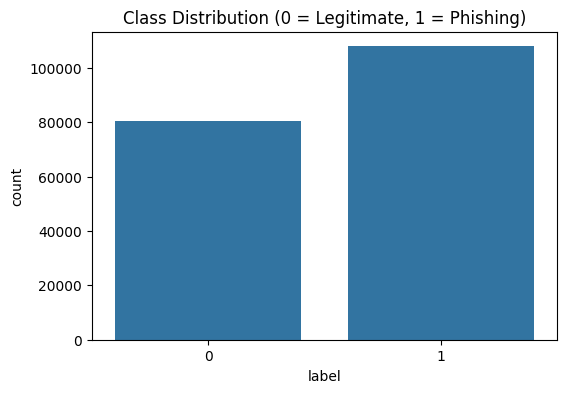

In [4]:
#plt.figure(figsize=(6,4))
sns.countplot(x='label', data=train_df)
plt.title('Class Distribution (0 = Legitimate, 1 = Phishing)')
plt.savefig('../plots/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
plt.figure(figsize=(6,4))
sns.countplot(x='label', data=train_df)
plt.title('Class Distribution (0 = Legitimate, 1 = Phishing)')
plt.savefig('../plots/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

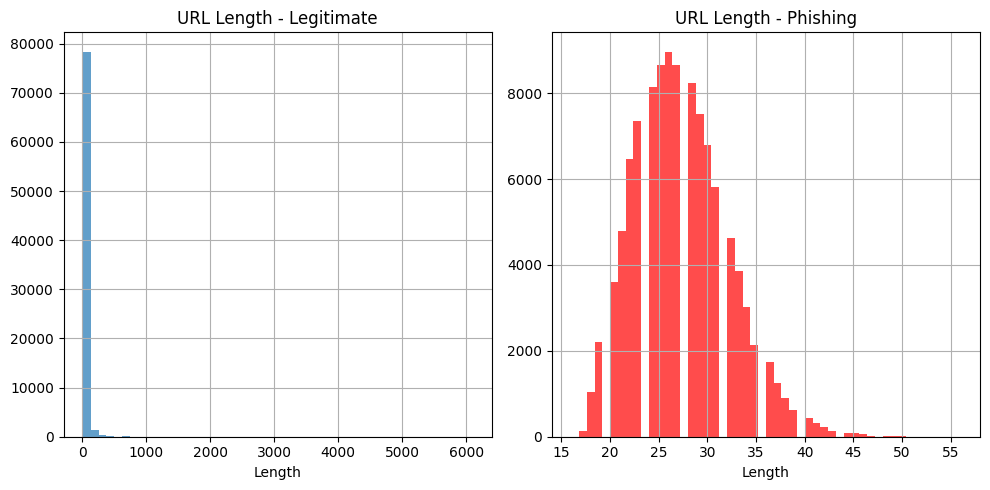

In [5]:
#URL length histograms by class
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
train_df[train_df['label']==0]['url_length'].hist(bins=50, alpha=0.7, label='Legitimate')
plt.title('URL Length - Legitimate')
plt.xlabel('Length')
plt.subplot(1,2,2)
train_df[train_df['label']==1]['url_length'].hist(bins=50, alpha=0.7, color='red', label='Phishing')
plt.title('URL Length - Phishing')
plt.xlabel('Length')
plt.tight_layout()
plt.savefig('../plots/url_length_hist.png', dpi=150)
plt.show()

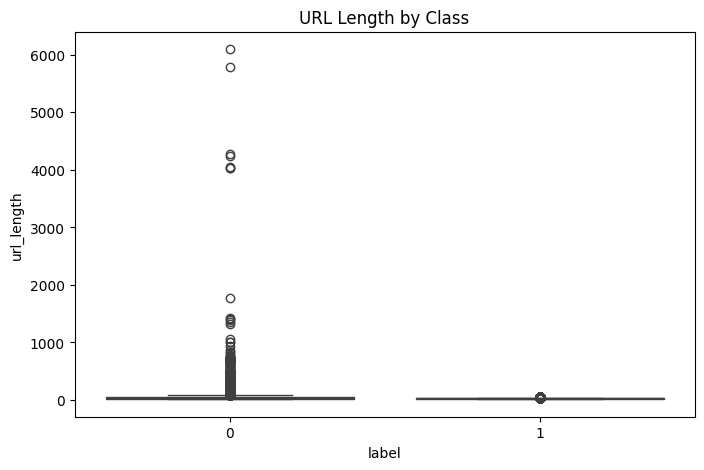

In [6]:
#Plots for numeric features
plt.figure(figsize=(8,5))
sns.boxplot(x='label', y='url_length', data=train_df)
plt.title('URL Length by Class')
plt.savefig('../plots/url_length_box.png', dpi=150)
plt.show()

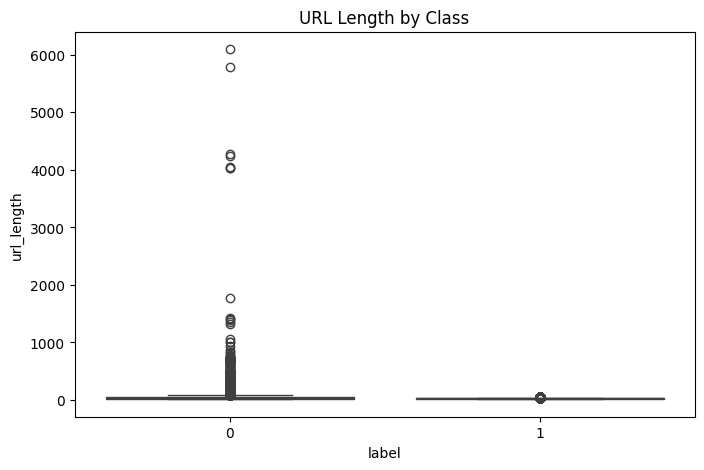

In [7]:
plt.figure(figsize=(8,5))
sns.boxplot(x='label', y='url_length', data=train_df)
plt.title('URL Length by Class')
plt.savefig('../plots/url_length_box.png', dpi=150)
plt.show()

In [8]:
train_df.groupby('label')['url_length'].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,80416.0,46.397334,63.552586,14.0,26.0,34.0,49.0,6097.0
1,107880.0,27.219308,4.813203,16.0,24.0,27.0,30.0,56.0
